LOAD

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/synthetic/transactions.csv")

df.head()

,transaction_id,account_id,merchant,category,amount,currency,city,latitude,longitude,timestamp,merchant_base_risk,is_fraud,fraud_type
0,TXN_000000001,ACC_005553,Uber,transport,361.05,INR,Chennai,13.094996,80.270734,2026-02-10 04:05:00,0.003,0,NaN
1,TXN_000000002,ACC_001241,Netflix,entertainment,189.96,INR,Kolkata,22.567489,88.340027,2026-01-10 21:24:00,0.002,0,NaN
2,TXN_000000003,ACC_007989,Flipkart,shopping,205.73,INR,Chennai,13.114307,80.270868,2026-06-18 22:00:00,0.015,0,NaN
3,TXN_000000004,ACC_001151,Swiggy,food,587.38,INR,Chennai,13.111508,80.261857,2026-03-09 23:46:00,0.005,0,NaN
4,TXN_000000005,ACC_004202,BookMyShow,entertainment,85.11,INR,Kolkata,22.580965,88.369709,2026-04-26 01:20:00,0.004,0,NaN


STRUCTURE


In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (150300, 13)

Columns:
['transaction_id', 'account_id', 'merchant', 'category', 'amount', 'currency', 'city', 'latitude', 'longitude', 'timestamp', 'merchant_base_risk', 'is_fraud', 'fraud_type']

Data types:
transaction_id            str
account_id                str
merchant                  str
category                  str
amount                float64
currency                  str
city                      str
latitude              float64
longitude             float64
timestamp                 str
merchant_base_risk    float64
is_fraud                int64
fraud_type                str
dtype: object

Missing values:
transaction_id             0
account_id                 0
merchant                   0
category                   0
amount                     0
currency                   0
city                       0
latitude                   0
longitude                  0
timestamp                  0
merchant_base_risk         0
is_fraud                   0
fraud_type     

Fraud distribution

In [4]:
fraud_counts = df["is_fraud"].value_counts()

print(fraud_counts)

print("\nFraud rate:")
print(df["is_fraud"].mean() * 100)

is_fraud
0    148040
1      2260
Name: count, dtype: int64

Fraud rate:
1.5036593479707252


Fraud types

In [5]:
df[df["is_fraud"] == 1]["fraud_type"].value_counts()

fraud_type
risky_merchant      488
geo_velocity        456
high_velocity       449
account_takeover    437
unusual_amount      430
Name: count, dtype: int64

Amount comparison

In [6]:
df.groupby("is_fraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,148040.0,288.683469,296.565758,-1.0,112.8000,200.880,356.8400,6826.08
1,2260.0,1732.853549,3386.667285,-1.0,156.6775,393.985,1732.3375,42279.70


Merchant behavior

In [7]:
merchant_fraud = (
    df.groupby("merchant")
      .agg(
          transactions=("transaction_id", "count"),
          frauds=("is_fraud", "sum")
      )
)

merchant_fraud["fraud_rate"] = (
    merchant_fraud["frauds"] /
    merchant_fraud["transactions"]
)

merchant_fraud.sort_values(
    "fraud_rate",
    ascending=False
)

,transactions,frauds,fraud_rate
merchant,,,
Unknown Merchant,3263,525,0.160895
BookMyShow,17790,222,0.012479
Myntra,11482,141,0.012280
BigBasket,13947,171,0.012261
Amazon,12309,146,0.011861
Zomato,16611,196,0.011799
Uber,19135,223,0.011654
Netflix,20833,240,0.011520
Croma,8283,95,0.011469


Fraud by city

In [8]:
city_fraud = (
    df.groupby("city")
      .agg(
          transactions=("transaction_id", "count"),
          frauds=("is_fraud", "sum")
      )
)

city_fraud["fraud_rate"] = (
    city_fraud["frauds"] /
    city_fraud["transactions"]
)

city_fraud.sort_values(
    "fraud_rate",
    ascending=False
)

,transactions,frauds,fraud_rate
city,,,
Bangalore,21067,349,0.016566
Kolkata,22583,345,0.015277
Mumbai,21156,323,0.015268
Delhi,20636,311,0.015071
Chennai,21776,317,0.014557
Pune,21568,309,0.014327
Hyderabad,21514,306,0.014223


Fraud types chart

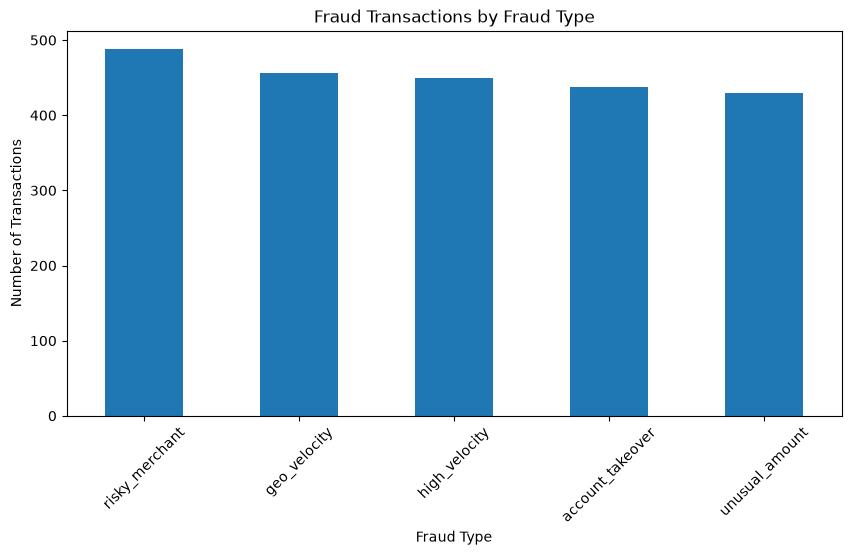

In [9]:
fraud_types = (
    df[df["is_fraud"] == 1]["fraud_type"]
    .value_counts()
)

fraud_types.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Fraud Transactions by Fraud Type")
plt.xlabel("Fraud Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

Amount distribution

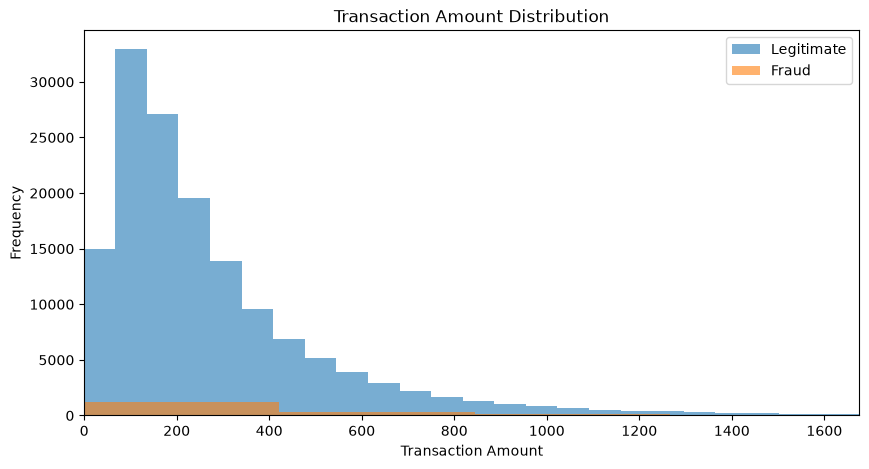

In [10]:
plt.figure(figsize=(10, 5))

plt.hist(
    df[df["is_fraud"] == 0]["amount"],
    bins=100,
    alpha=0.6,
    label="Legitimate"
)

plt.hist(
    df[df["is_fraud"] == 1]["amount"],
    bins=100,
    alpha=0.6,
    label="Fraud"
)

plt.xlim(0, df["amount"].quantile(0.99))

plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("Transaction Amount Distribution")
plt.legend()

plt.show()

In [11]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values(
    ["account_id", "timestamp"]
).reset_index(drop=True)

df.to_csv(
    "../data/synthetic/transactions_sorted.csv",
    index=False
)

print(df[["account_id", "timestamp"]].head(10))

   account_id           timestamp
0  ACC_000001 2026-01-09 07:07:00
1  ACC_000001 2026-01-22 09:55:00
2  ACC_000001 2026-01-24 05:02:00
3  ACC_000001 2026-03-03 16:08:00
4  ACC_000001 2026-03-05 02:46:00
5  ACC_000001 2026-03-06 08:17:00
6  ACC_000001 2026-03-26 14:46:00
7  ACC_000001 2026-04-30 00:22:00
8  ACC_000001 2026-06-06 22:47:00
9  ACC_000001 2026-06-07 02:49:00
